#### Imports

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

# Import KMRF class
from kmrf import KMRF
from KMRF_training_config import *

# Set visualization style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("✓ Libraries imported successfully")
print(f"  Pandas version: {pd.__version__}")
print(f"  NumPy version: {np.__version__}")

✓ Libraries imported successfully
  Pandas version: 2.3.3
  NumPy version: 2.3.4


## 1. Configure KMRF Model

In [20]:
# Create DataFrame of asset names
asset_names_df = pd.DataFrame({
    'Investment Universe ETFs': get_assets_by_class('universe') + ['']*7,
    'US Equity ETFs': get_assets_by_class('us_equity'),
    'Commodities': get_assets_by_class('commodity') + ['']*5,
    'International Equity ETFs': get_assets_by_class('int_equity') + ['']*11,

})

from pandas import option_context
with option_context('display.max_colwidth', None):
    display(asset_names_df)

,Investment Universe ETFs,US Equity ETFs,Commodities,International Equity ETFs
0,IVV - iShares Core S&P 500 ETF,SPDR S&P 500 ETF,Gold Futures,Vanguard Total International Stock ETF
1,IJH - iShares Core S&P Mid-Cap ETF,Invesco QQQ Trust,Wheat Futures,Vanguard FTSE Developed Markets ETF
2,IWM - iShares Russell 2000 ETF,iShares Russell 2000 ETF,Corn Futures,Vanguard FTSE Emerging Markets ETF
3,EFA - iShares MSCI EAFE ETF,SPDR Dow Jones Industrial Average ETF,Copper,Vanguard FTSE Europe ETF
4,EEM - iShares MSCI Emerging Markets ETF,Energy Select Sector SPDR,Sugar,Vanguard FTSE Pacific ETF
5,AGG - iShares Core U.S. Aggregate Bond ETF,Financial Select Sector SPDR,Silver Futures,iShares China Large-Cap ETF
6,SPTL - SPDR Portfolio Long Term Treasury ETF,Utilities Select Sector SPDR,US Dollar,iShares MSCI Japan ETF
7,HYG - iShares iBoxx $ High Yield Corporate Bond ETF,Industrial Select Sector SPDR,Soybean Futures,iShares MSCI India ETF
8,SPBO - SPDR Portfolio Corporate Bond ETF,Health Care Select Sector SPDR,Lumber Futures,
9,IYR - iShares U.S. Real Estate ETF,Technology Select Sector SPDR,Live Cattle Futures,


In [21]:
TRAINING_CONFIG = KMRF_Training_Config(
    asset_name= 'EFA - iShares MSCI EAFE ETF',
    classification_type='original',
    use_data_type='master',
    feature_window_size=1,
    feature_asset_classes=['us_equity', 'commodity', 'int_equity'],
    cross_asset_specific=[],  # empty means all (only referring to universe assets)
    use_boruta_selection=False,
    use_consensus_selection=True
)
# You can also set cross_assets_to_include separately and pass it explicitly
# cross_assets_to_include = []

## 2. Initialize KMRF Model

In [22]:
# Initialize KMRF model with new features
model = KMRF(
    asset_class=TRAINING_CONFIG.get_asset_class(),
    asset_name=TRAINING_CONFIG.get_asset_name(),
    classification_type=TRAINING_CONFIG.get_classification_type(),
    end_date=TRAINING_CONFIG.get_date_ranges()['end_date'],
    use_data_type=TRAINING_CONFIG.get_use_data_type(),
    feature_window_size=TRAINING_CONFIG.get_feature_window_size(),  
    feature_asset_classes=TRAINING_CONFIG.get_cross_asset_features(),
    cross_asset_specific=TRAINING_CONFIG.get_cross_asset_specific(),
    xgb_params=TRAINING_CONFIG.get_xgb_params(),
    use_boruta_selection=TRAINING_CONFIG.get_use_boruta_selection(),
    use_consensus_selection=TRAINING_CONFIG.get_use_consensus_selection()
)

print("\n" + "="*80)
print("KMRF MODEL INITIALIZED")
print("="*80)

KMRF model initialized
  Asset: EFA - iShares MSCI EAFE ETF
  Asset class: universe
  Classification type: original
  End date: 20190101
  Data type: master
  Data path: /Users/jessegoodman/Desktop/Stevens MFE/Sem3/FE800/FE800_project_code/data/master_df.csv
  KAMA+MSR model directory: /Users/jessegoodman/Desktop/Stevens MFE/Sem3/FE800/FE800_project_code/saved_models/KAMA_MSR/universe/20190101
  Validation period: 2019-02-01 to 2021-12-30
  Test start: 2022-02-01
  Random seed: 1010
  Feature window size: 1 days
  Feature asset classes: ['us_equity', 'commodity', 'int_equity']
  Feature selection: Boruta=False, Consensus=True
  Custom XGB parameters: {'n_estimators': 220, 'max_depth': 13, 'learning_rate': 0.1, 'subsample': 0.8, 'colsample_bytree': 0.25, 'min_child_weight': 95, 'gamma': 0.045, 'random_state': 1010, 'n_jobs': -1, 'tree_method': 'hist', 'enable_categorical': False}

KMRF MODEL INITIALIZED


## 3. Run Training Pipeline

In [23]:
model.pipeline(optimize=False)


KMRF PIPELINE FOR EFA - iShares MSCI EAFE ETF
Asset Class: universe
Classification Type: original
Data Type: master
Feature Asset Classes: ['us_equity', 'commodity', 'int_equity']
Cross-Asset Specifics: []
    ^ if empty, uses all assets in 'Feature Asset Classes'
Feature Window Size: 1
Use Boruta Selection: False
Use Consensus Selection: True

[Step 1/10] Loading Data...

Loading data from: /Users/jessegoodman/Desktop/Stevens MFE/Sem3/FE800/FE800_project_code/data/master_df.csv
Loaded data for: EFA - iShares MSCI EAFE ETF
  Rows: 6083
  Columns: 95
  Date range: 2001-08-17 00:00:00 to 2025-10-24 00:00:00

[Step 2/10] Computing Features...

Extracting pre-computed features for EFA - iShares MSCI EAFE ETF...
  Features shape: (6083, 95)

[Step 3/10] Loading KAMA+MSR Labels...

LOADING KAMA+MSR LABELS FOR EFA - iShares MSCI EAFE ETF
Loading from: /Users/jessegoodman/Desktop/Stevens MFE/Sem3/FE800/FE800_project_code/data/master_label_df.csv
✓ Loaded labels for: EFA - iShares MSCI EAFE ET

## 4. Generate & Visualize Predictions


GENERATING VALIDATION PREDICTIONS

Generating predictions...
  Input shape: (735, 773)
  Using pre-selected features: 773
✓ Generated probability predictions: (735, 4)

Prediction probabilities shape: (735, 4)
Columns: ['P(LV_Bull)', 'P(LV_Bear)', 'P(HV_Bull)', 'P(HV_Bear)']

Sample predictions (first 10 days):
            P(LV_Bull)  P(LV_Bear)  P(HV_Bull)  P(HV_Bear)
date                                                      
2019-02-01    0.994346    0.002150    0.002480    0.001024
2019-02-04    0.992201    0.003055    0.003344    0.001401
2019-02-05    0.991291    0.003355    0.003773    0.001581
2019-02-06    0.996188    0.001331    0.001749    0.000733
2019-02-07    0.997087    0.000999    0.001349    0.000565
2019-02-08    0.996417    0.001806    0.001248    0.000529
2019-02-11    0.965430    0.027483    0.004905    0.002183
2019-02-12    0.991097    0.005321    0.002478    0.001103
2019-02-13    0.993719    0.003242    0.002135    0.000904
2019-02-14    0.993917    0.002826   

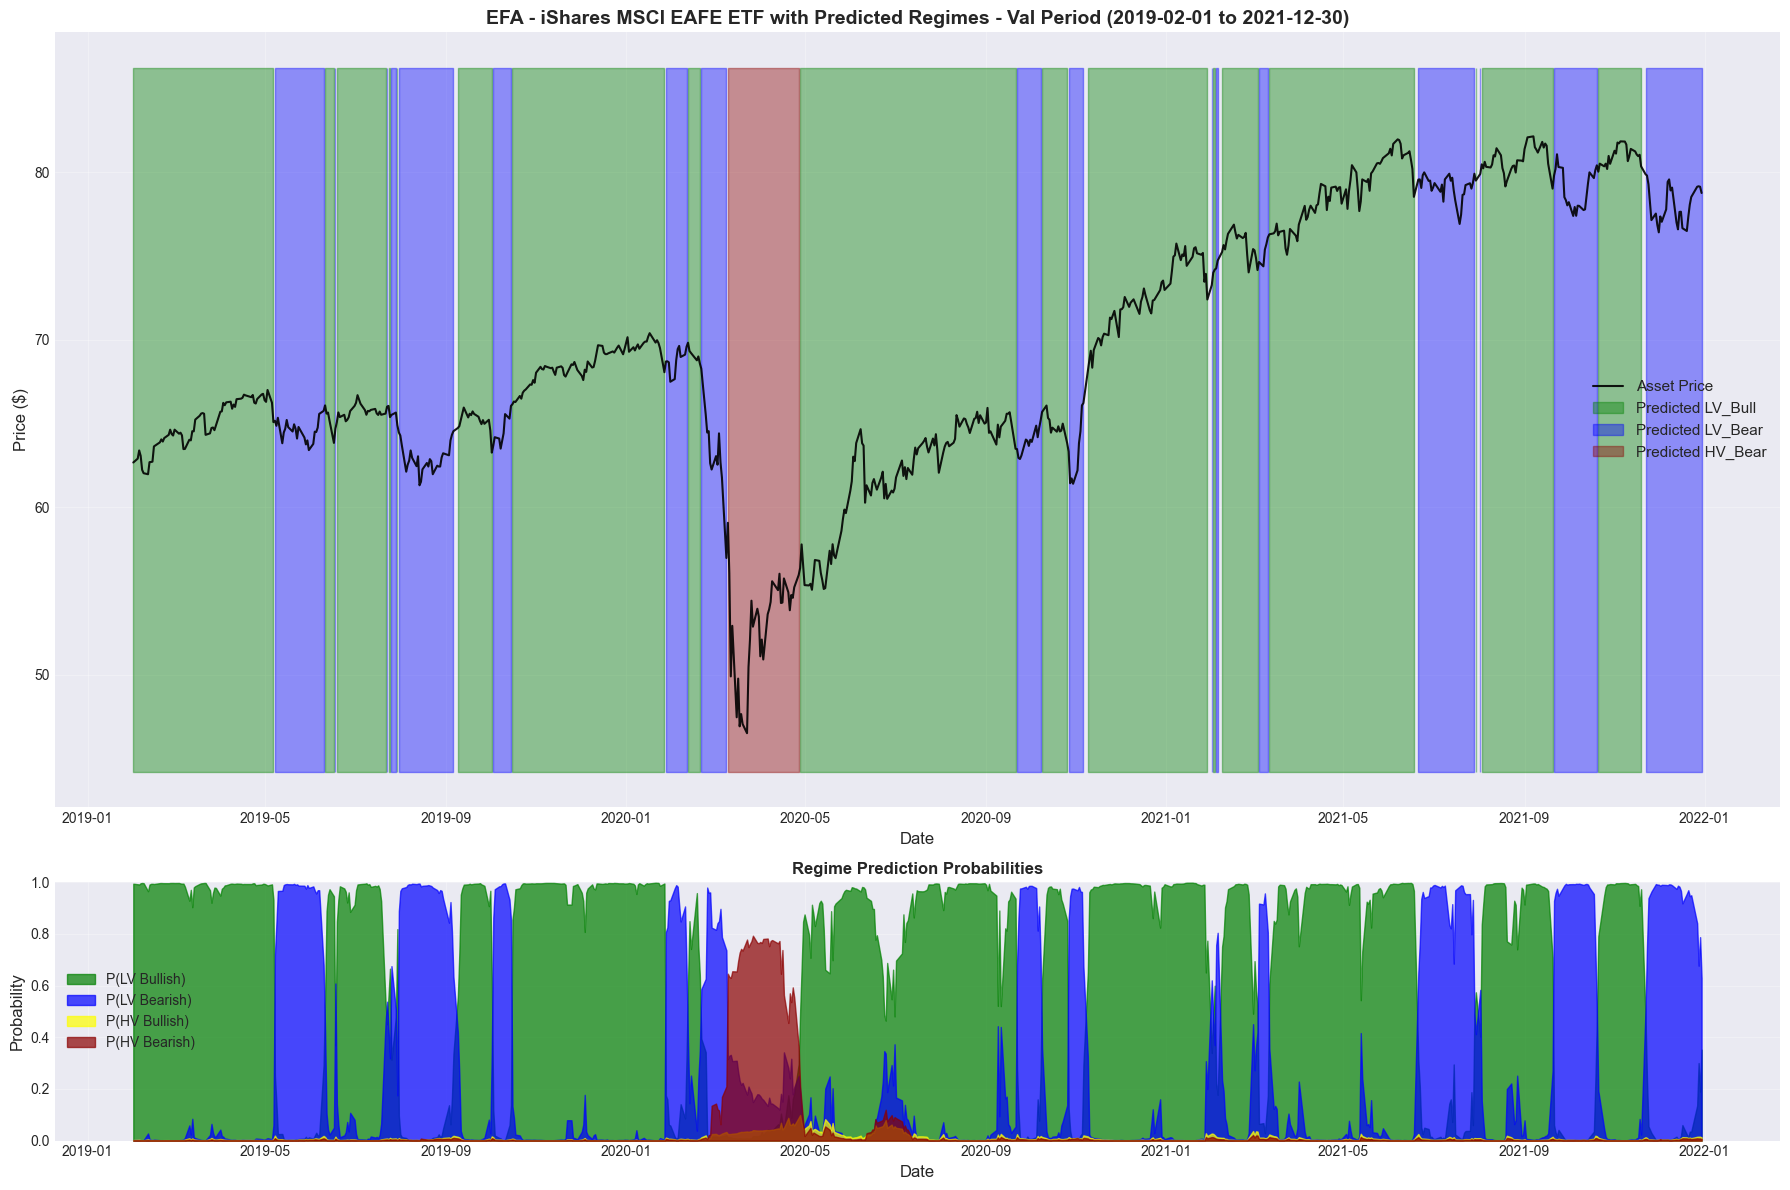

In [24]:
# Make predictions on validation set
print("\n" + "="*80)
print("GENERATING VALIDATION PREDICTIONS")
print("="*80)
test_or_val_set = 'val'  # Change to 'test' or 'val' as needed

y_val_pred_proba = model.predict(test_or_val=test_or_val_set)

print(f"\nPrediction probabilities shape: {y_val_pred_proba.shape}")
print(f"Columns: {list(y_val_pred_proba.columns)}")
print(f"\nSample predictions (first 10 days):")
print(y_val_pred_proba.head(10))

# Visualize predictions
print("\n" + "="*80)
print("VISUALIZING PREDICTIONS")
print("="*80)
model.viz_predictions(test_or_val=test_or_val_set)

<Axes: xlabel='date'>

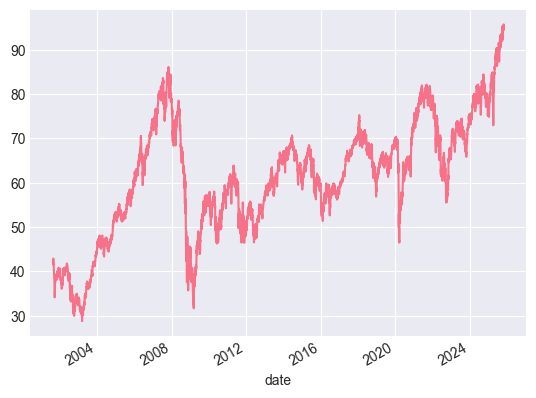

In [25]:
model.raw_ohlc.droplevel(0, axis=1)['close'].plot()

## 5. Save Model

In [26]:
# path = f'saved_models/KMRF_new/{model.classification_type}/{model.asset_class}/'
# path += f'{model.asset_name.replace(" ", "_")}_KMRF_model.pkl'
# model.save_model(path)